In [1]:
# # Sweep Results Visualization 
#
# This notebook loads sweep_results.csv and produces:
# 1) Metric heatmaps per controller with shared color scale
# 2) Heatmaps for t_settle_after and ITAE (shared color scales, brighter = better)


# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib.lines as mlines



In [2]:
# %%
# Path to the sweep results CSV (edit if needed)
CSV_PATH = "sweep_results/sweep_results_7_by_7.csv"

df = pd.read_csv(CSV_PATH)

required_cols = {"perturb_percent", "perturb_time", "controller", "metric_M", "t_settle_after", "ITAE"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

df.head()

,perturb_percent,perturb_time,controller,t_settle_after,ITAE,metric_M,rise_time,overshoot,settling_time_abs,rank_M,is_best
0,20,360,PID-GS,199.222222,3791.806527,0.600764,-40.565657,5.398456,559.222222,1.0,True
1,20,360,FF,600.000000,9440.152211,1.598028,-40.565657,1.545814,960.000000,5.0,False
2,20,360,PID-FF,384.636364,6259.331703,1.045957,-40.565657,8.929543,744.636364,4.0,False
3,20,360,PID-GS-FF,295.929293,4405.013261,0.762602,-40.565657,6.967935,655.929293,2.0,False
4,20,360,PID,330.575758,4938.354510,0.853660,-40.565657,7.687703,690.575758,3.0,False


In [3]:
# %%
# Ensure consistent ordering on axes
percents = np.sort(df["perturb_percent"].unique())
times = np.sort(df["perturb_time"].unique())

# controllers_sorted = sorted(df["controller"].unique())
controllers_sorted = ['PID', 'PID-GS', 'PID-GS-FF']

# Color dictionary
color_dict = {
    'set_point_1': '#6759d4',
    'set_point_2': '#ebab4b',
    'green': 'green',
    'red': 'red',
    'PID': 'black',
    'PID-GS': '#1f78b4', 
    'FF': '#dd3497',
    'PID-FF': '#fc8d62',
    'PID-GS-FF': '#03cea4'
}

print("percents:", percents)
print("times:", times)
print("controllers:", controllers_sorted)

percents: [20 30 40 50 60 70 80]
times: [360 390 420 450 480 510 540]
controllers: ['PID', 'PID-GS', 'PID-GS-FF']


In [4]:
# %%
def pivot_metric(df_in: pd.DataFrame, controller: str, value_col: str) -> pd.DataFrame:
    sub = df_in[df_in["controller"] == controller].copy()
    mat = sub.pivot(index="perturb_percent", columns="perturb_time", values=value_col)
    mat = mat.reindex(index=percents, columns=times)
    return mat

def global_limits(df_in: pd.DataFrame, value_col: str):
    v = df_in[value_col].to_numpy(dtype=float)
    vmin = np.nanmin(v[np.isfinite(v)])
    vmax = np.nanmax(v[np.isfinite(v)])
    return vmin, vmax

# %%
# Global limits for shared scales (per quantity)
metric_vmin, metric_vmax = global_limits(df, "metric_M")
ts_vmin, ts_vmax = global_limits(df, "t_settle_after")
itae_vmin, itae_vmax = global_limits(df, "ITAE")

metric_vmin, metric_vmax = 0.5, 5

#print("Global metric_M limits:", metric_vmin, metric_vmax)
print("Global t_settle_after limits:", ts_vmin, ts_vmax)
print("Global ITAE limits:", itae_vmin, itae_vmax)

Global t_settle_after limits: 0.0 600.0
Global ITAE limits: 354.31662832692814 13670.703956837331


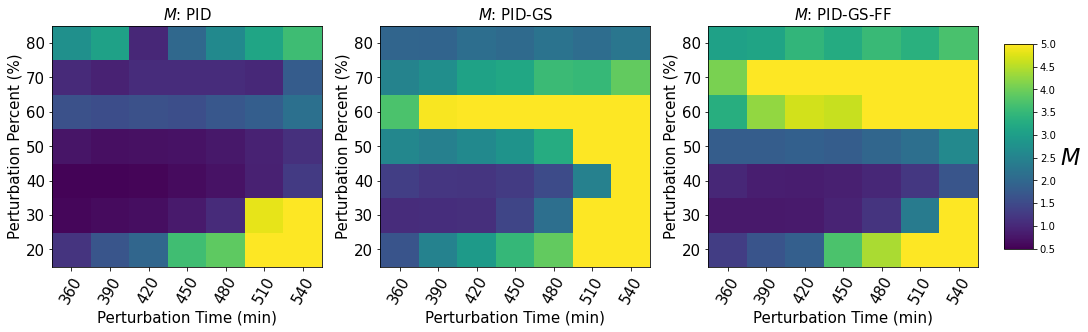

In [5]:
# %% [markdown]
# Heatmaps of metric_M for each controller
# Shared color scale across controllers and brighter = better (lower metric_M).

# %%
n = len(controllers_sorted)
ncols = 3
nrows = int(np.ceil(n / ncols))
tick_fontsize = 15

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(5.0 * ncols, 4.5 * nrows),
    constrained_layout=True
)

axes = np.atleast_2d(axes)

# Use a reversed colormap so low values appear bright
cmap_heatmaps = "viridis"

im_for_cbar = None

for idx, ctrl in enumerate(controllers_sorted):
    r = idx // ncols
    c = idx % ncols
    ax = axes[r, c]

    mat = pivot_metric(df, ctrl, "metric_M")
    data = 1/mat.values.astype(float)

    # Mask invalid values (nan/inf)
    data = np.ma.masked_invalid(data)

    im = ax.imshow(
        data,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        vmin=metric_vmin,
        vmax=metric_vmax,
        cmap=cmap_heatmaps
    )

    if im_for_cbar is None:
        im_for_cbar = im

    ax.set_title(r"$M$" + f": {ctrl}", fontsize=tick_fontsize)
    ax.set_xticks(np.arange(len(times)))
    ax.set_xticklabels(np.round(times, 0), rotation=60, fontsize=tick_fontsize)
    ax.set_yticks(np.arange(len(percents)))
    ax.set_yticklabels(np.round(percents, 0), fontsize=tick_fontsize)
    ax.set_xlabel("Perturbation Time (min)", fontsize=tick_fontsize)
    ax.set_ylabel("Perturbation Percent (%)", fontsize=tick_fontsize)

# Turn off unused axes
for j in range(n, nrows * ncols):
    r = j // ncols
    c = j % ncols
    axes[r, c].axis("off")

# One shared colorbar for the entire figure
cbar = fig.colorbar(im_for_cbar, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label(r"$M$", fontsize=tick_fontsize*1.5, rotation=0, labelpad=15)

plt.show()

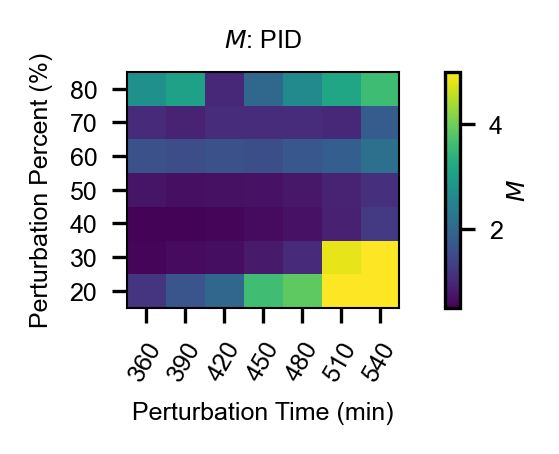

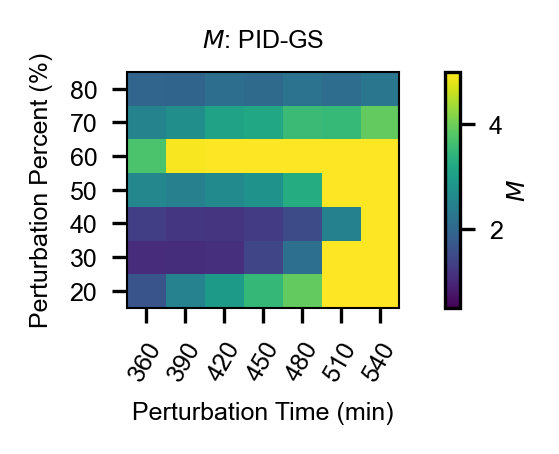

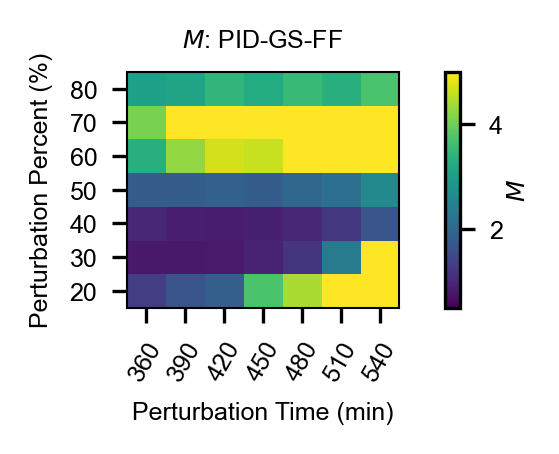

In [6]:
## Publication Quality Figures:

# Heatmaps of metric_M for each controller
# One config dict used for all individual heatmap figures

heatmap_cfg = {
    'figsize': (1.75, 1.4),
    'dpi': 300,
    'font_family': 'Arial',
    'base_fontsize': 6,
    'title_fontsize': 6,
    'label_fontsize': 6,
    'tick_fontsize': 6,
    'cbar_label_fontsize': 6,
    'spine_linewidth': 0.5,
    'xtick_rotation': 60,
    'cmap': 'viridis',
    'interpolation': 'nearest',
    'aspect': 'auto',
    'origin': 'lower',
    'cbar_orientation': 'vertical',
    'cbar_shrink': 1,
    'cbar_pad': 0.05,
    'cbar_labelpad': 1
}

plt.rcParams.update({
    'font.family': heatmap_cfg['font_family'],
    'font.size': heatmap_cfg['base_fontsize'],
    'axes.labelsize': heatmap_cfg['label_fontsize'],
    'axes.titlesize': heatmap_cfg['title_fontsize'],
    'xtick.labelsize': heatmap_cfg['tick_fontsize'],
    'ytick.labelsize': heatmap_cfg['tick_fontsize']
})

for ctrl in controllers_sorted:
    fig, ax = plt.subplots(
        figsize=heatmap_cfg['figsize'],
        dpi=heatmap_cfg['dpi'],
        constrained_layout=True
    )

    mat = pivot_metric(df, ctrl, "metric_M")
    data = 1 / mat.values.astype(float)

    # Mask invalid values (nan/inf)
    data = np.ma.masked_invalid(data)

    im = ax.imshow(
        data,
        origin=heatmap_cfg['origin'],
        aspect=heatmap_cfg['aspect'],
        interpolation=heatmap_cfg['interpolation'],
        vmin=metric_vmin,
        vmax=metric_vmax,
        cmap=heatmap_cfg['cmap']
    )

    ax.set_title(r"$M$: " + f"{ctrl}", fontsize=heatmap_cfg['title_fontsize'])
    ax.set_xticks(np.arange(len(times)))
    ax.set_xticklabels(
        np.round(times, 0),
        rotation=heatmap_cfg['xtick_rotation'],
        fontsize=heatmap_cfg['tick_fontsize']
    )
    ax.set_yticks(np.arange(len(percents)))
    ax.set_yticklabels(
        np.round(percents, 0),
        fontsize=heatmap_cfg['tick_fontsize']
    )
    ax.set_xlabel("Perturbation Time (min)", fontsize=heatmap_cfg['label_fontsize'])
    ax.set_ylabel("Perturbation Percent (%)", fontsize=heatmap_cfg['label_fontsize'])

    # Configurable spine width
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_linewidth(heatmap_cfg['spine_linewidth'])

    ax.tick_params(axis='both', which='major', labelsize=heatmap_cfg['tick_fontsize'])

    # Horizontal colorbar
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation=heatmap_cfg['cbar_orientation'],
        shrink=heatmap_cfg['cbar_shrink'],
        pad=heatmap_cfg['cbar_pad']
    )
    cbar.set_label(
        r"$M$",
        fontsize=heatmap_cfg['cbar_label_fontsize'],
        labelpad=heatmap_cfg['cbar_labelpad']
    )
    cbar.ax.tick_params(labelsize=heatmap_cfg['tick_fontsize'])

    safe_ctrl = ctrl.replace('/', '_').replace(' ', '_')
    plt.savefig(
        f'figures/heatmap_metric_M_{safe_ctrl}.svg',
        format='svg',
        dpi=heatmap_cfg['dpi'],
        bbox_inches='tight',
        transparent=True
    )

    plt.show()

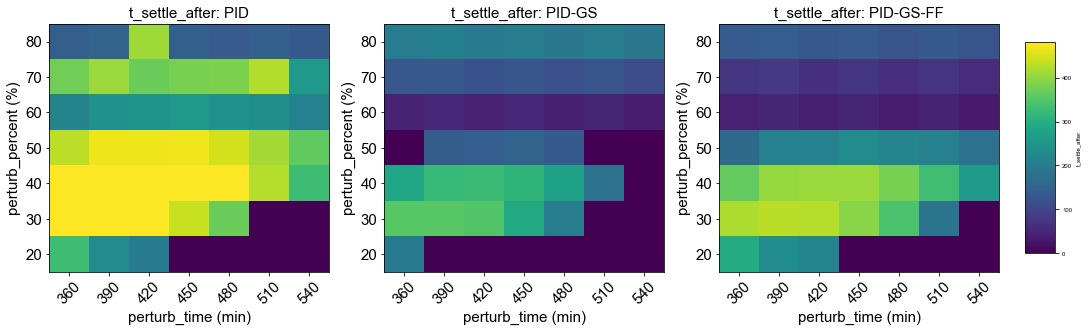

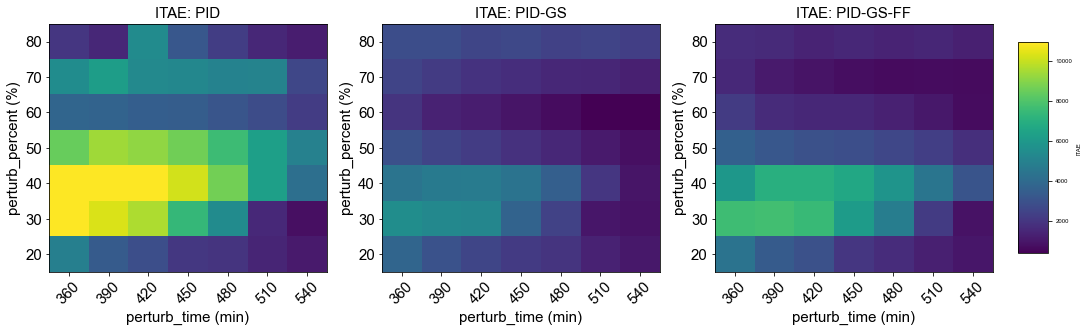

In [7]:
# Additional Plots
# Heatmaps for t_settle_after and ITAE

# %%
value_cols = [
    ("t_settle_after", ts_vmin, ts_vmax),
    ("ITAE", itae_vmin, itae_vmax),
]

tick_fontsize = 15

for val, vmin, vmax in value_cols:
    n = len(controllers_sorted)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5.0 * ncols, 4.5 * nrows),
        constrained_layout=True
    )

    axes = np.atleast_2d(axes)

    im_for_cbar = None

    for idx, ctrl in enumerate(controllers_sorted):
        r = idx // ncols
        c = idx % ncols
        ax = axes[r, c]

        mat = pivot_metric(df, ctrl, val)
        data = mat.values.astype(float)
        data = np.ma.masked_invalid(data)

        im = ax.imshow(
            data,
            origin="lower",
            aspect="auto",
            interpolation="nearest",
            vmin=vmin,
            vmax=vmax*0.8,
            cmap=cmap_heatmaps  
        )

        if im_for_cbar is None:
            im_for_cbar = im

        ax.set_title(f"{val}: {ctrl}", fontsize=tick_fontsize)
        ax.set_xticks(np.arange(len(times)))
        ax.set_xticklabels(times, rotation=45, fontsize=tick_fontsize)
        ax.set_yticks(np.arange(len(percents)))
        ax.set_yticklabels(percents, fontsize=tick_fontsize)
        ax.set_xlabel("perturb_time (min)", fontsize=tick_fontsize)
        ax.set_ylabel("perturb_percent (%)", fontsize=tick_fontsize)
    for j in range(n, nrows * ncols):
        r = j // ncols
        c = j % ncols
        axes[r, c].axis("off")

    cbar = fig.colorbar(im_for_cbar, ax=axes.ravel().tolist(), shrink=0.85)
    cbar.set_label(f"{val}")

    plt.show()